# Cardio Dataset - Data Preprocessing and EDA

Based on the uploaded preprocessing guide.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler


df=pd.read_csv('cardio_train.csv',sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 1. Understand the Data

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## 2. Handle Missing Values

In [6]:
df.isnull().sum()
for col in df.select_dtypes(include='number').columns:
    df[col]=df[col].fillna(df[col].median())

## 3. Remove Duplicate Rows

In [7]:
print(df.duplicated().sum())
df=df.drop_duplicates()

0


## 4. Detect and Handle Outliers (IQR - Weight)

In [8]:
Q1=df['weight'].quantile(0.25)
Q3=df['weight'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df=df[(df['weight']>=lower)&(df['weight']<=upper)]

## 5. Encode Categorical Variables

In [ ]:
le=LabelEncoder()
for col in ['gender','cholesterol','gluc','smoke','alco','active','cardio']:
    df[col]=le.fit_transform(df[col])

## 6. Normalize Numerical Features

In [10]:
scaler=MinMaxScaler()
cols=['age','height','weight','ap_hi','ap_lo']
df[cols]=scaler.fit_transform(df[cols])

## 7. Exploratory Data Analysis

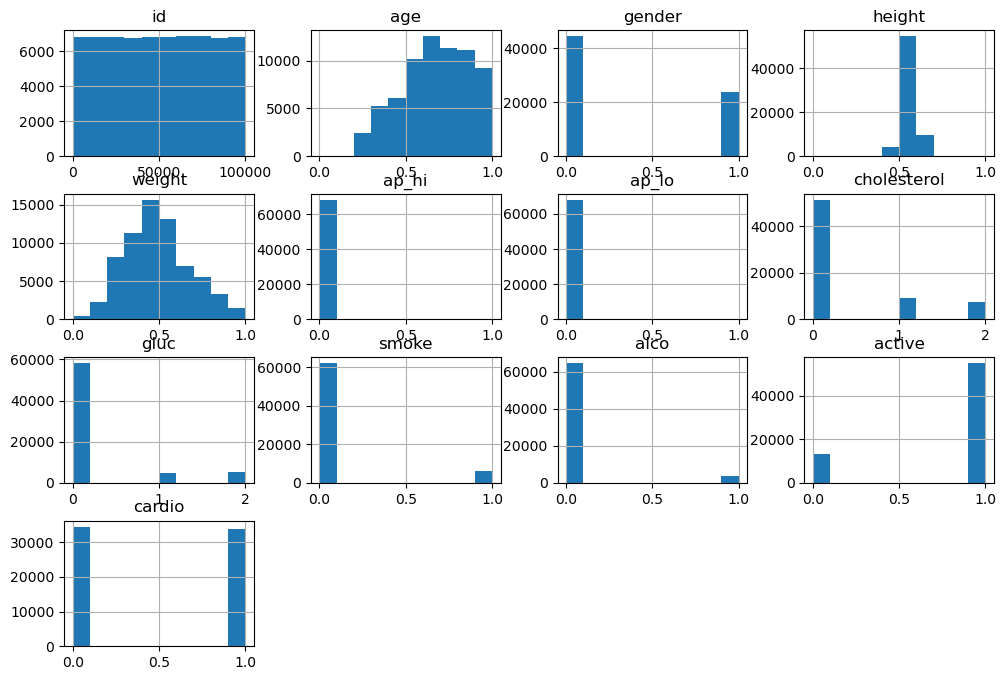

In [11]:
df.hist(figsize=(12,8))
plt.show()

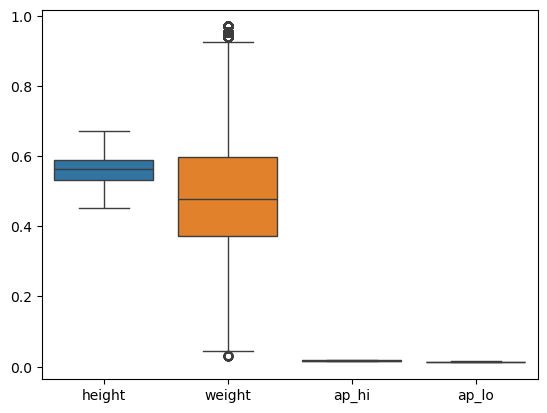

In [17]:
sns.boxplot(data=df[['height','weight','ap_hi','ap_lo']])
plt.show()

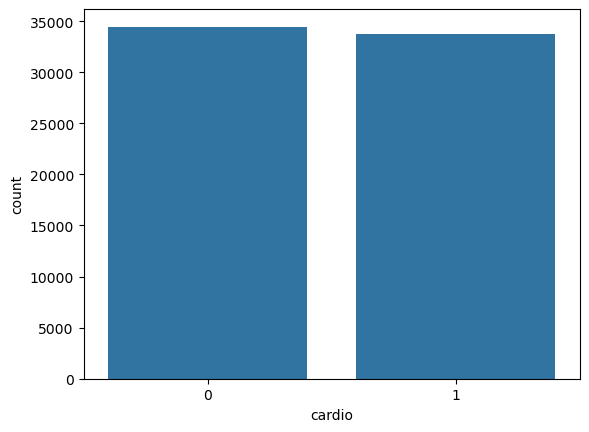

In [10]:
sns.countplot(x='cardio',data=df)
plt.show()

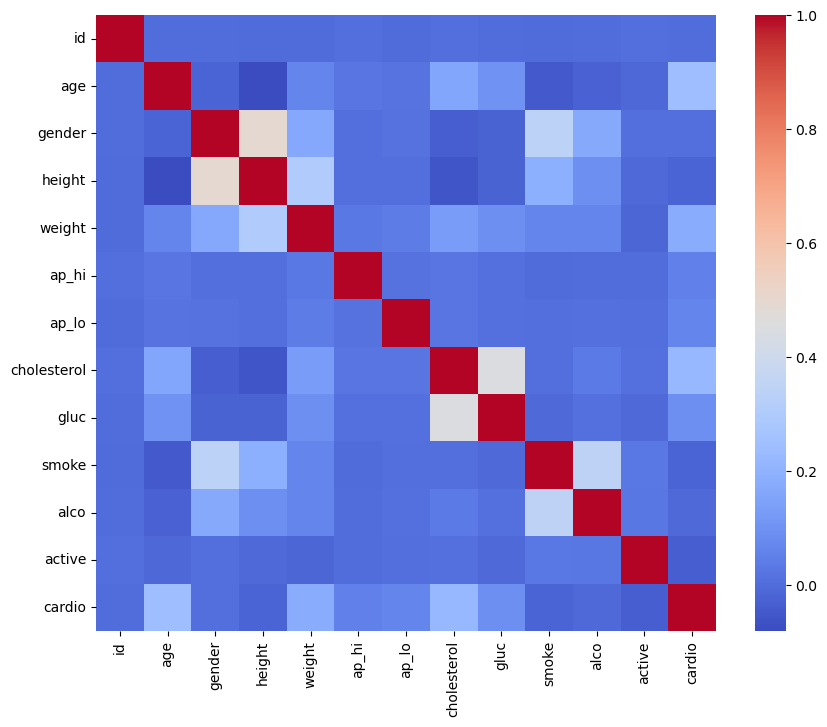

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),cmap='coolwarm')
plt.show()

## Handle Outliers for height

In [13]:
Q1=df['height'].quantile(0.25)
Q3=df['height'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print("Lower Bound:",lower)
print("Upper Bound:",upper)
print("Total Outliers:",((df['height']<lower)|(df['height']>upper)).sum())
df=df[(df['height']>=lower)&(df['height']<=upper)]
print(df.shape)

Lower Bound: 0.4487179487179487
Upper Bound: 0.6743589743589744
Total Outliers: 458
(67723, 13)


## Handle Outliers for weight

In [14]:
Q1=df['weight'].quantile(0.25)
Q3=df['weight'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print("Lower Bound:",lower)
print("Upper Bound:",upper)
print("Total Outliers:",((df['weight']<lower)|(df['weight']>upper)).sum())
df=df[(df['weight']>=lower)&(df['weight']<=upper)]
print(df.shape)

Lower Bound: 0.014925373134328568
Upper Bound: 0.9701492537313432
Total Outliers: 331
(67392, 13)


## Handle Outliers for ap_hi

In [15]:
Q1=df['ap_hi'].quantile(0.25)
Q3=df['ap_hi'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print("Lower Bound:",lower)
print("Upper Bound:",upper)
print("Total Outliers:",((df['ap_hi']<lower)|(df['ap_hi']>upper)).sum())
df=df[(df['ap_hi']>=lower)&(df['ap_hi']<=upper)]
print(df.shape)

Lower Bound: 0.01484230055658627
Upper Bound: 0.019789734075448363
Total Outliers: 1295
(66097, 13)


## Handle Outliers for ap_lo

In [16]:
Q1=df['ap_lo'].quantile(0.25)
Q3=df['ap_lo'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print("Lower Bound:",lower)
print("Upper Bound:",upper)
print("Total Outliers:",((df['ap_lo']<lower)|(df['ap_lo']>upper)).sum())
df=df[(df['ap_lo']>=lower)&(df['ap_lo']<=upper)]
print(df.shape)

Lower Bound: 0.012195121951219513
Upper Bound: 0.015808491418247517
Total Outliers: 3883
(62214, 13)
